## Classification using embeddings

There are many ways to classify text. This notebook shares an example of text classification using embeddings. For many text classification tasks, we've seen fine-tuned models do better than embeddings. See an example of fine-tuned models for classification in [Fine-tuned_classification.ipynb](Fine-tuned_classification.ipynb). We also recommend having more examples than embedding dimensions, which we don't quite achieve here.

In this text classification task, we predict the score of a food review (1 to 5) based on the embedding of the review's text. We split the dataset into a training and a testing set for all the following tasks, so we can realistically evaluate performance on unseen data. The dataset is created in the [Obtain_dataset Notebook](Obtain_dataset.ipynb).


In [1]:
# imports
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# load data
datafile_path = "data/fine_food_reviews_with_embeddings_1k.csv"

df = pd.read_csv(datafile_path)
df["embedding"] = df.embedding.apply(eval).apply(np.array)  # convert string to array

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    list(df.embedding.values), df.Score, test_size=0.2, random_state=42
)

# train random forest classifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
probas = clf.predict_proba(X_test)

report = classification_report(y_test, preds)
print(report)


              precision    recall  f1-score   support

           1       1.00      0.25      0.40        20
           2       1.00      0.38      0.55         8
           3       1.00      0.18      0.31        11
           4       1.00      0.26      0.41        27
           5       0.73      1.00      0.85       134

    accuracy                           0.76       200
   macro avg       0.95      0.41      0.50       200
weighted avg       0.82      0.76      0.70       200



In [3]:
df

,Unnamed: 0,ProductId,UserId,Score,Summary,Text,combined,n_tokens,embedding
0,0,B003XPF9BO,A3R7JR3FMEBXQB,5,where does one start...and stop... with a tre...,Wanted to save some to bring to my Chicago fam...,Title: where does one start...and stop... wit...,52,"[0.007018072064965963, -0.02731654793024063, 0..."
1,297,B003VXHGPK,A21VWSCGW7UUAR,4,"Good, but not Wolfgang Puck good","Honestly, I have to admit that I expected a li...","Title: Good, but not Wolfgang Puck good; Conte...",178,"[-0.003140551969408989, -0.009995664469897747,..."
2,296,B008JKTTUA,A34XBAIFT02B60,1,Should advertise coconut as an ingredient more...,"First, these should be called Mac - Coconut ba...",Title: Should advertise coconut as an ingredie...,78,"[-0.01757248118519783, -8.266511576948687e-05,..."
3,295,B000LKTTTW,A14MQ40CCU8B13,5,Best tomato soup,I have a hard time finding packaged food of an...,Title: Best tomato soup; Content: I have a har...,111,"[-0.0013932279543951154, -0.011112828738987446..."
4,294,B001D09KAM,A34XBAIFT02B60,1,Should advertise coconut as an ingredient more...,"First, these should be called Mac - Coconut ba...",Title: Should advertise coconut as an ingredie...,78,"[-0.01757248118519783, -8.266511576948687e-05,..."
...,...,...,...,...,...,...,...,...,...
995,623,B0000CFXYA,A3GS4GWPIBV0NT,1,Strange inflammation response,Truthfully wasn't crazy about the taste of the...,Title: Strange inflammation response; Content:...,110,"[0.00011091353371739388, -0.00466986745595932,..."
996,624,B0001BH5YM,A1BZ3HMAKK0NC,5,My favorite and only MUSTARD,You've just got to experience this mustard... ...,Title: My favorite and only MUSTARD; Content:...,80,"[-0.020869314670562744, -0.013138455338776112,..."
997,625,B0009ET7TC,A2FSDQY5AI6TNX,5,My furbabies LOVE these!,Shake the container and they come running. Eve...,Title: My furbabies LOVE these!; Content: Shak...,47,"[-0.009749102406203747, -0.0068712360225617886..."
998,619,B007PA32L2,A15FF2P7RPKH6G,5,got this for the daughter,all i have heard since she got a kuerig is why...,Title: got this for the daughter; Content: all...,50,"[-0.00521062919870019, 0.0009606690146028996, ..."


We can see that the model has learnt to distinguish between the categories decently. 5-star reviews show the best performance overall, and this is not too surprising, since they are the most common in the dataset.

RandomForestClassifier() - Average precision score over all classes: 0.87


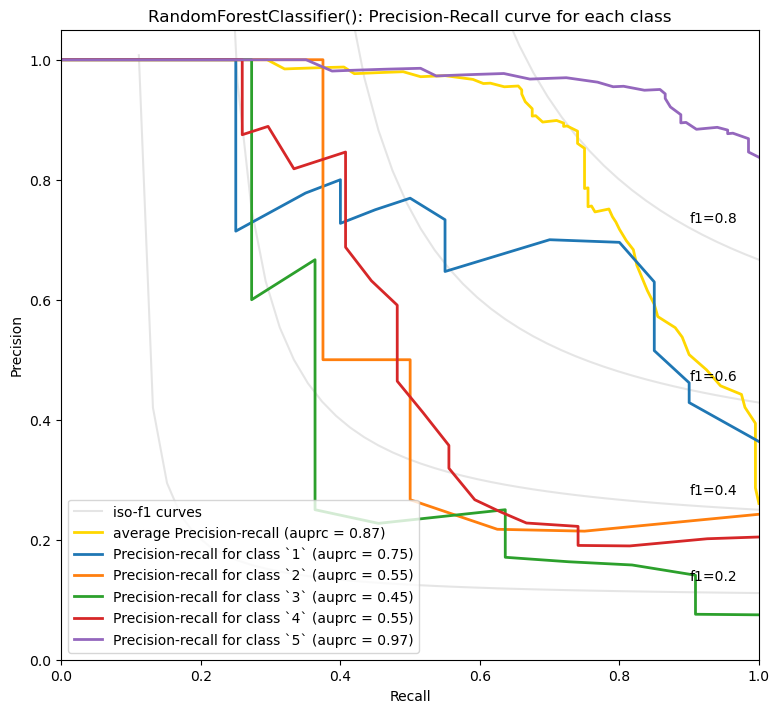

In [2]:
from openai.embeddings_utils import plot_multiclass_precision_recall

plot_multiclass_precision_recall(probas, y_test, [1, 2, 3, 4, 5], clf)


Unsurprisingly 5-star and 1-star reviews seem to be easier to predict. Perhaps with more data, the nuances between 2-4 stars could be better predicted, but there's also probably more subjectivity in how people use the inbetween scores.